In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})


mapping = {
    'ta': 'Temperature',
    'p':  'Pressure',
    'dd': 'Wind Direction',
    'rr': 'Precipitation',
    'Tx': 'Maximum Temperature',
    'Tn': 'Minimum Temperature',
    'rh': 'Relative Humidity',
    'w': 'Wind Speed',
    'fs': 'Fresh Snow',
    'rrt': 'Type of Precipitation',
    'eee': 'Snow Depth',
    'other': 'Other'
}

# marker mapping
var_markers = {
    "ta": "o", # circle
    "p":  "D", # diamond
    "rr": "s", # square
    "dd": "p", # pentagon
    "w":  "*", # star
    "Tn": "v", # down arrow
    "Tx": "^", # up arrow
    "other": "X"  # or "h" (hexagon), "8" (octagon), etc.
}

OTHER_VARS = ["eee", "rrt", "fs", "rh", "w"]
OTHER_COLOR = '#aec7e8'  # gray-blue for "Other"

# Order of importance (Bottom of chart = First in list)
importance_order = ['ta', 'p', 'dd', 'rr', 'Tx', 'Tn', 'other']

# Define the Professional Color Map
color_map = {
    'Temperature': '#d62728',         # Strong Red
    'Maximum Temperature': '#ff7f0e', # Orange
    'Minimum Temperature': '#ffbb78', # Light Orange
    'Pressure': '#9467bd',            # Purple
    'Precipitation': '#1f77b4',       # Deep Blue
    'Wind Direction': '#2ca02c',      # Green
    'Wind Speed': '#9edae5',          # Sky Blue
    'Relative Humidity': '#17becf',   # Teal
    'Fresh Snow': '#dbdb8d',          # Pale Yellow/White-ish
    'Other' : OTHER_COLOR
}

MAP_DOMAIN = [-25, 61.5, 29.8, 73]
unibern = "#8a1e22" # color for the poster
unibern_red = "#e4003c"

you need to run `sef_series_length_v2.py` before. 

Run it like this:

`python sef_series_length_v2.py /scratch3/PALAEO-RA/daily_data/final -o sef_series_summary_v2.csv --max-gap-days 366`

In [2]:
df = pd.read_csv("sef_series_summary_v2.csv")
df.head()

,station_source,variable,stat,series_index,start,end,span_days,span_years,n_files,max_internal_gap_days,blocks
0,ACRE_Bessested,p,point,1,1749-08-01,1751-07-30,729,2.00,1,0,1749-08-01..1751-07-30
1,Barriendos_Barcelona,p,point,1,1811-01-01,1820-12-31,3653,10.00,1,0,1811-01-01..1820-12-31
2,Barriendos_Cadiz,Tn,min,1,1786-08-01,1949-12-31,59687,163.42,1,0,1786-08-01..1949-12-31
3,Barriendos_Cadiz,Tx,max,1,1786-08-01,1949-12-31,59687,163.42,1,0,1786-08-01..1949-12-31
4,Barriendos_Cadiz,p,mean,1,1820-01-01,1949-12-31,47482,130.00,1,0,1820-01-01..1949-12-31


In [3]:
df["variable"] = df["variable"].str.replace(r"_.*", "", regex=True)
df["variable"].value_counts()

variable
ta     538
p      534
rr     289
dd     113
Tn     108
Tx     104
w       31
rh      19
eee      8
rrt      6
fs       2
Name: count, dtype: int64

In [4]:
# delete the vars I don't want to see more
# df = df[~df["variable"].isin(["eee", "rrt", "fs", "rh", "w"])]
df["variable"] = df["variable"].apply(lambda v: "other" if v in OTHER_VARS else v)

bins = np.arange(0, df["span_years"].max() + 1, 1)  # yearly bins

bins_log = np.logspace(
    np.log10(df["span_years"].min()),
    np.log10(df["span_years"].max()),
    20
)

# Timeseires Number of Series

_Option 1_: real years with series

In [5]:
df_years = pd.read_csv("sef_active_years_1803.csv")
df_years["variable"] = df_years["variable"].apply(lambda v: "other" if v in OTHER_VARS else v)

# drop a handful of corrupted Year values from the raw SEF data (e.g. "183" instead of "1830")
df_years = df_years[(df_years["year"] >= 1600) & (df_years["year"] <= 2030)]


In [6]:
ts_by_var = (
    df_years
    .groupby(["year", "variable"])
    .size()
    .reset_index(name="n_series")
)

# Pivot the data so years are rows and variables are columns
ts_pivot = (
    ts_by_var.pivot(index='year', columns='variable', values='n_series').fillna(0)  # Fill missing combinations with 0
)

if "other" in ts_pivot.columns:
    pass

# filter by years of interest
ts_pivot = ts_pivot[ts_pivot.index < 1901]
ts_pivot.tail()

variable,Tn,Tx,dd,other,p,rr,ta
year,,,,,,,
1896,27.0,27.0,5.0,9.0,74.0,161.0,65.0
1897,26.0,26.0,6.0,10.0,82.0,161.0,66.0
1898,26.0,26.0,6.0,10.0,82.0,162.0,66.0
1899,25.0,25.0,6.0,10.0,83.0,162.0,66.0
1900,24.0,23.0,6.0,10.0,84.0,165.0,65.0


Same plot but with bigger labels for poster

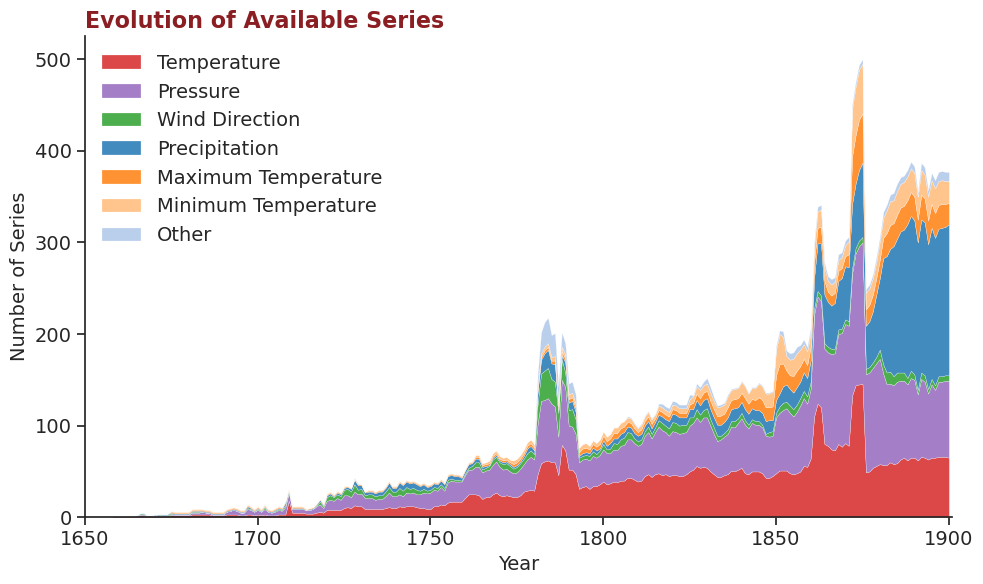

In [7]:
# Filter and Order columns based on importance (Bottom to Top)
plot_order = [v for v in importance_order if v in ts_pivot.columns]

ts_plot = ts_pivot[plot_order]

# Map columns to long names for the legend
labels = [mapping.get(v, v) for v in plot_order]
colors = [color_map.get(mapping.get(v, v), '#7f7f7f') for v in plot_order]

# 3. Plotting
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(10, 6))

# Use stackplot for a clean, professional "accumulation" look
ax.stackplot(
    ts_plot.index, 
    ts_plot.values.T, # transpose the matrix to match (n_vars, n_years)
    labels=labels, 
    colors=colors, 
    alpha=0.85,
    edgecolor='white',
    linewidth=0.2
)

# 4. Legend (Reversed to show 'ta' at the top of the legend)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    loc='upper left', 
    fontsize=14,
    bbox_to_anchor=(0, 1),
    frameon=False
)

# 5. Final Polish
# ax.set_title("Evolution of Available Series", fontsize=16,
#             fontweight='bold', loc='left')
ax.set_xlabel("Year", fontsize=14)
ax.set_xlim(1650,1901)
ax.set_ylabel("Number of Series", fontsize=14)
ax.set_ylim(0)
ax.tick_params(axis='both', labelsize=14)
sns.despine()

ax.set_title("Evolution of Available Series", fontsize=16, color=unibern,
             fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig("image/series_over_time_stacked-poster.svg", bbox_inches='tight')
plt.savefig("image/series_over_time_stacked-poster.pdf", bbox_inches='tight')

plt.show()

# Pie Chart number of Series

In [8]:
len(df)

1752

### Pie Chart from Metadata_summary file

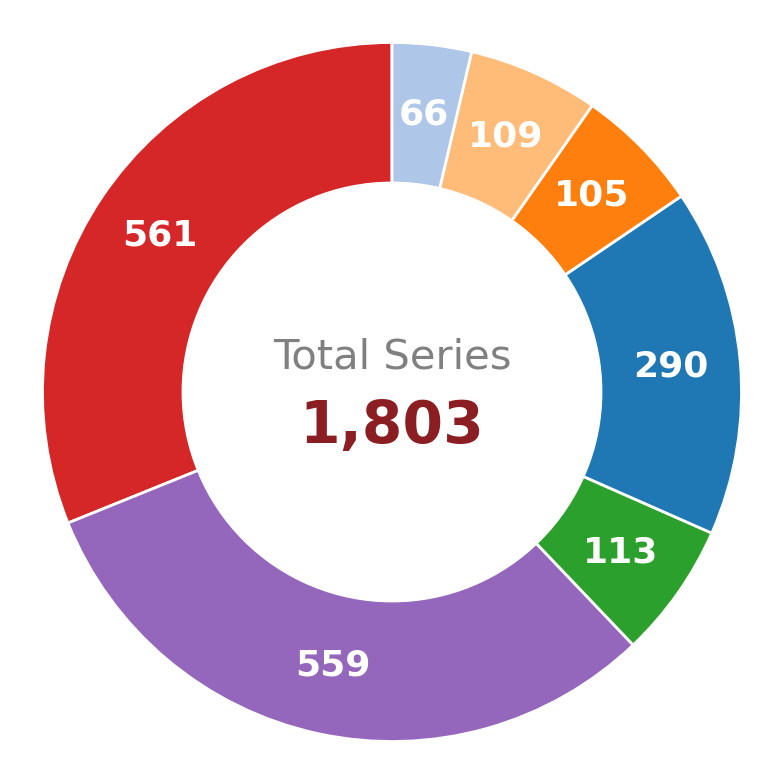

In [9]:
# Load and prep data
df = pd.read_csv("metadata_summary_names.csv")
df_filtered = df.copy()
df_filtered["variable"] = df_filtered["Vbl"].apply(lambda v: "other" if v in OTHER_VARS else v)

# Count the number of series per variable
counts = df_filtered['variable'].value_counts().reset_index()
counts.columns = ['variable', 'count']

# Map to long names
counts['variable_long'] = counts['variable'].map(mapping).fillna("Other")

# Sort by importance order so the chart reads predictably clockwise
counts['sort_key'] = counts['variable'].apply(lambda x: importance_order.index(x) if x in importance_order else 99)
counts = counts.sort_values('sort_key')

# Extract plotting lists
labels = counts['variable_long'].tolist()
sizes = counts['count'].tolist()
colors = [OTHER_COLOR if label == "Other" else color_map.get(label, '#7f7f7f') for label in labels]
total_series = sum(sizes)

def count_and_pct(pct):
    absolute = int(round(pct * total_series / 100.0))
    return f"{absolute}"

# Create the Donut Chart
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    autopct=count_and_pct,
    startangle=90,
    pctdistance=0.80,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_fontsize(26)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig.gca().add_artist(centre_circle)

ax.text(0, 0.1, "Total Series", ha='center', va='center', fontsize=30, color='gray')
ax.text(0, -0.1, f"{total_series:,}", ha='center', color=unibern,
        va='center', fontsize=42, fontweight='bold')

ax.axis('equal')
plt.tight_layout()
plt.savefig("image/pie_chart_variables_poster.svg", bbox_inches='tight')
plt.savefig("image/pie_chart_variables_poster.pdf", bbox_inches='tight')
plt.show()

**Combine The Figures**

In [10]:
import cairosvg
from PIL import Image
from io import BytesIO
from IPython.display import display

load the figures

In [11]:
DPI_SCALE = 4  # 4x for ~300dpi

# Convert SVGs to high-res PNGs
bg_png = cairosvg.svg2png(url="image/series_over_time_stacked-poster.svg", scale=DPI_SCALE)
fg_png = cairosvg.svg2png(url="image/pie_chart_variables_poster.svg", scale=DPI_SCALE)

bg = Image.open(BytesIO(bg_png)).convert("RGBA")
fg = Image.open(BytesIO(fg_png)).convert("RGBA")

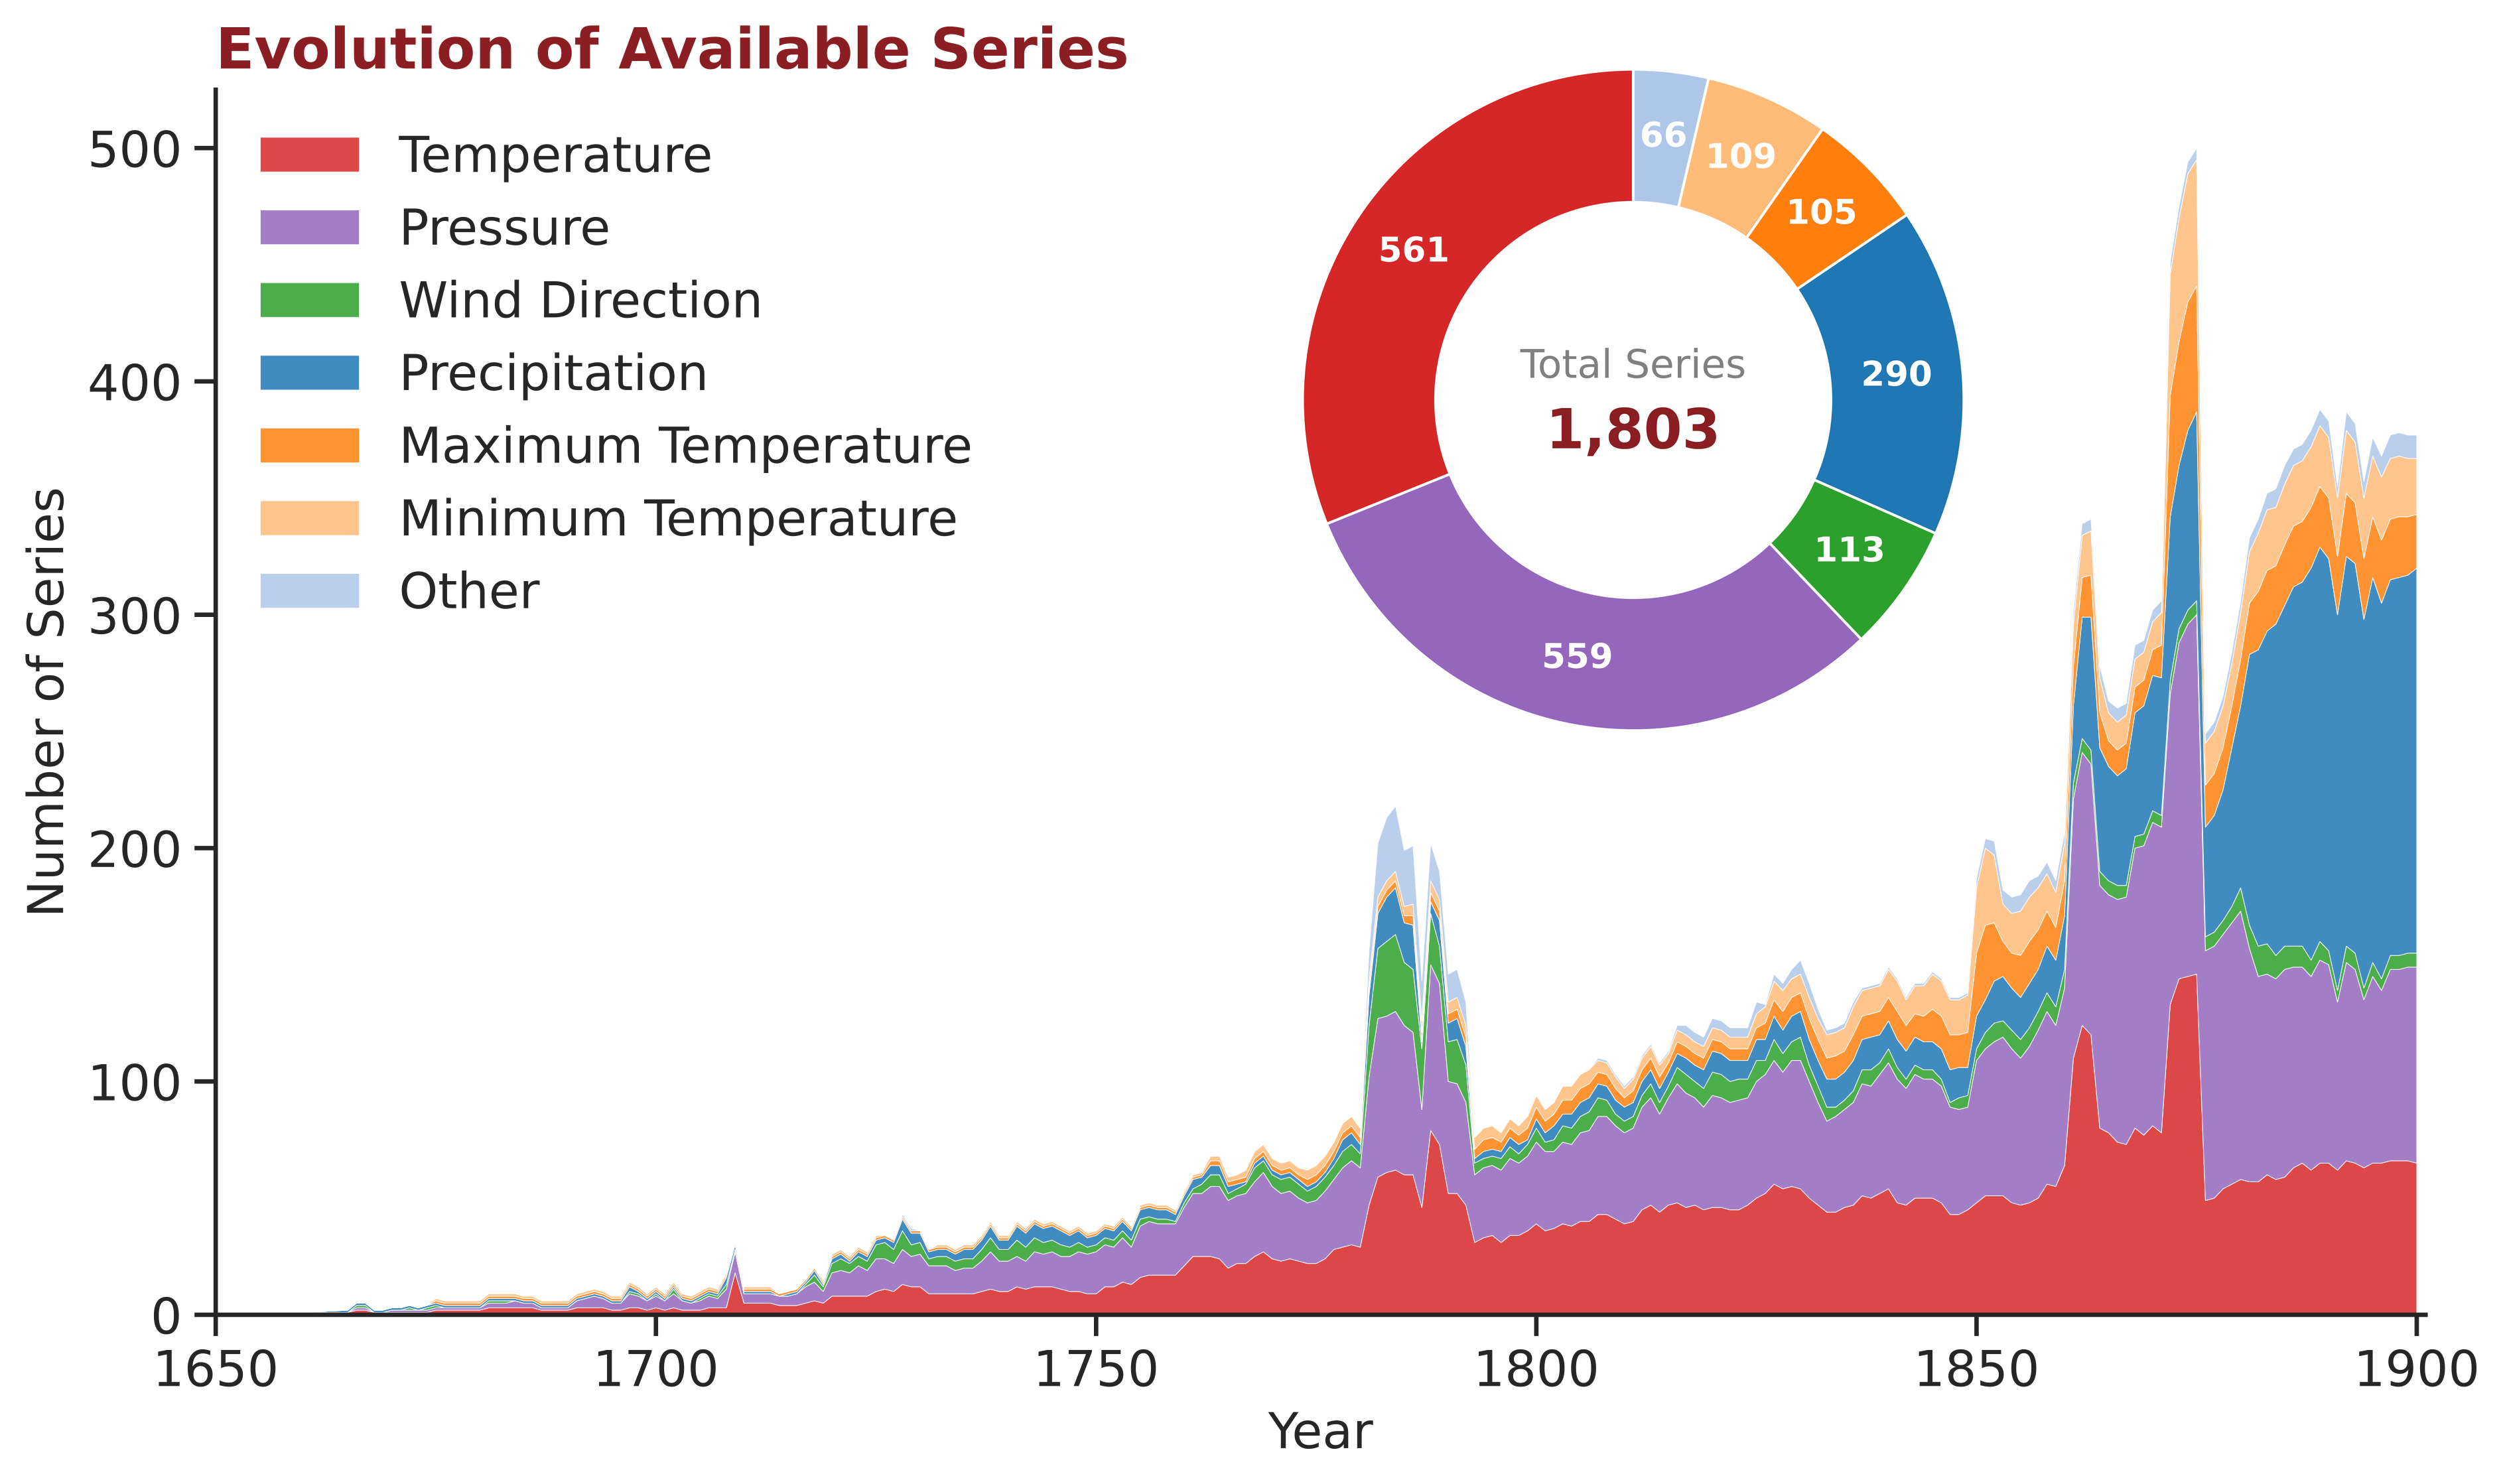

In [12]:
# Scale pie to ~55% of background height
target_h = int(bg.height * 0.5)
ratio = target_h / fg.height
fg_resized = fg.resize((int(fg.width * ratio), target_h), Image.LANCZOS)

# Position: upper-right corner with a small margin
x = bg.width - fg_resized.width - int(bg.width * 0.2)
y = int(bg.height * 0.02)

# Composite and save
bg.paste(fg_resized, (x, y), fg_resized)
bg.save("/home/ccorbella/scratch2_symboliclink/code/dataprep/image/combined_figure_poster.png", dpi=(300, 300))
bg.convert("RGB").save("/home/ccorbella/scratch2_symboliclink/code/dataprep/image/combined_figure_poster.pdf", dpi=(300, 300))
display(bg)

# Start Year Maps

In [13]:
df_meta = pd.read_csv("/scratch3/PALAEO-RA/daily_data/inventory.csv")
df_meta.columns

Index(['dirname', 'Names', 'filename', 'ID', 'Name', 'Lat', 'Lon', 'Alt',
       'Source', 'Link', 'Vbl', 'Stat', 'Units', 'start_date', 'end_date',
       'Meta'],
      dtype='object')

In [14]:
df_v2 = pd.read_csv('/scratch2/ccorbella/code/dataprep/sef_series_summary_v2.csv')
df_v2.columns

Index(['station_source', 'variable', 'stat', 'series_index', 'start', 'end',
       'span_days', 'span_years', 'n_files', 'max_internal_gap_days',
       'blocks'],
      dtype='object')

link the two tables (metadata_summary and sef_series_summary_v2) so that we can extract Lat and Lon

In [15]:
import re

# extract keys from metadata filenames
DATE_BLOCK_RE = re.compile(r"(\d{8})[-_](\d{8})")

def extract_keys(filename):
    match = DATE_BLOCK_RE.search(filename)
    if not match:
        return (None, None)
    left = filename[:match.start()].rstrip("_")
    right = filename[match.end():].lstrip("_").replace(".tsv", "").replace(".TSV", "")
    var = right.split("_")[0]
    return left, var # returns (station_source, variable

# Apply parser to metadata to create matching keys
keys = df_meta["filename"].apply(lambda x: pd.Series(extract_keys(x)))
df_meta["station_source"] = keys[0]
df_meta["variable"] = keys[1]

# 3. Get unique coordinates for each station/variable
# Since all files for a given station/var share the same location, we just take the first one
df_coords = df_meta.dropna(subset=["station_source", "variable"]).drop_duplicates(subset=["station_source", "variable"])
df_coords = df_coords[["station_source", "variable", "Lat", "Lon"]]

# 4. Merge coordinates into your V2 summary
df_map = df_v2.merge(df_coords, on=["station_source", "variable"], how="left")


Plot as a 2x3 layout

Plot station maps for the poster

In [16]:
start_year = df_map['start'].str.split("-").str[0].astype(int)
end_year   = df_map['end'].str.split("-").str[0].astype(int)

# define bins for colors
bins   = [-9999, 1700, 1750, 1800, 1850, 1900]
labels = ["<1700", "1700–1749", "1750–1799", "1800–1849", ">1850"]

df_map["start_period"] = pd.cut(start_year, bins=bins, labels=labels)

################################################################

# sequential colors for periods
colors = sns.color_palette("plasma", len(labels))[::-1]

# numeric codes for color values
codes = df_map["start_period"].cat.codes
cats  = df_map["start_period"].cat.categories

# Target variables in the exact requested order (left-right, top-bottom)
valid_vars = ["ta", "rr","p", "dd"] 

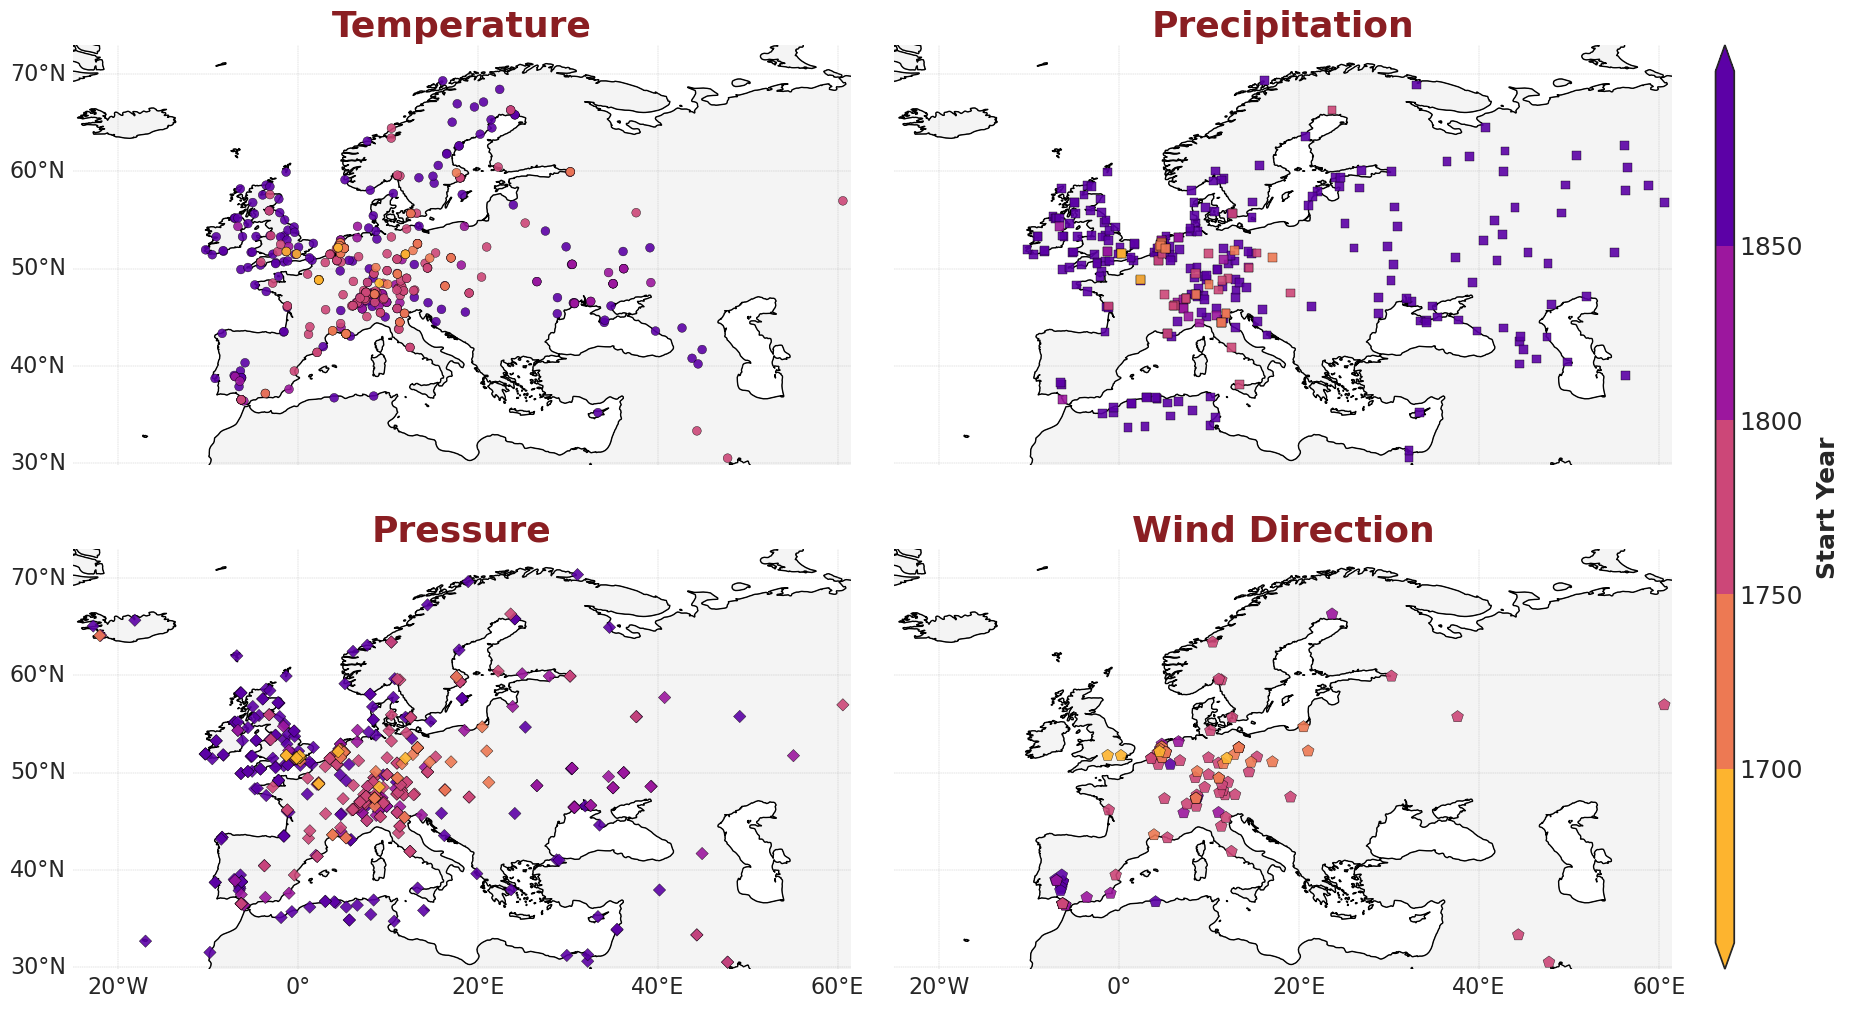

In [17]:
# make plot
fig = plt.figure(figsize=(22, 12))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 0.08], wspace=0.08, hspace=0.2)

axes = [
    fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree()),
]

# Flatten the 2x2 axes array into a 1D list for easy iteration
#axes = axes.flatten()

for i, var in enumerate(valid_vars):
    ax = axes[i]
    
    df_var = df_map[df_map["variable"] == var].copy()

    # Sort descending so oldest years are at the bottom of the DF and drawn LAST (on top)
    df_var = df_var.sort_values(by="start", ascending=False)
    
    df_var_codes = df_var["start_period"].cat.codes
    point_colors = [colors[code] for code in df_var_codes]

    ax.set_extent(MAP_DOMAIN, crs=ccrs.PlateCarree())
    ax.set_aspect('auto')  # Let Cartopy handle the aspect ratio for geographic accuracy

    # Add contours
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    ax.add_feature(cfeature.LAND, facecolor='#f4f4f4', edgecolor='black')
    for spine in ax.spines.values():
        spine.set_visible(False)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i in [0, 2])    # ta and p
    gl.bottom_labels = (i in [2, 3])  # p, rr
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}


    # plot all points at once and color by period using 'ax' instead of 'plt'
    ax.scatter(
        df_var["Lon"].astype(float),
        df_var["Lat"].astype(float),
        facecolor=point_colors,
        s=80 if var == "dd" else 40,
        edgecolor="black",
        linewidth=0.3,
        marker=var_markers.get(var, "o"),
        transform=ccrs.PlateCarree(),
        label=var,
        alpha=0.9,
        zorder=3
    )

    # Safely get the mapping title, defaulting to the variable name if not found
    title_text = mapping.get(var, var)
    ax.set_title(f"{title_text}", fontsize=26, fontweight='bold', color=unibern)

ax_leg = fig.add_subplot(gs[:, 2])
ax_leg.axis('off')

cmap_discrete = ListedColormap(colors)
bounds = np.arange(-0.5, len(labels), 1)
norm = BoundaryNorm(bounds, cmap_discrete.N)

cbar_ax = ax_leg.inset_axes([0, 0, 0.3, 1])
sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax, extend='both', extendfrac=0.03)
cbar.ax.yaxis.set_tick_params(which='both', length=0)
cbar.set_ticks([0.5, 1.5, 2.5, 3.5])
cbar.set_ticklabels(["1700", "1750", "1800", "1850"], fontsize=18)
cbar.set_label("Start Year", fontsize=18, fontweight='bold', labelpad=10)

# Save the single grid figure
plt.savefig("/scratch2/ccorbella/code/dataprep/image/station_map_start_year_poster.svg", bbox_inches="tight")
plt.savefig("/scratch2/ccorbella/code/dataprep/image/station_map_start_year_poster.pdf", bbox_inches="tight")

plt.show()
plt.close()

# Winter 1829/30 panel

In [18]:
import netCDF4 as nc
import warnings
warnings.filterwarnings('ignore')
unibern = "#8a1e22"

In [19]:
# ── 1. Load 20CRv3 ──────────────────────────────────────────────────────────

def load_20cr(year):
    ds = nc.Dataset(f'/scratch2/ccorbella/files/20CRv3_misc/TMP2m_daymean_Europe/anl_mean_{year}_TMP_2m_daymean_Europe.nc')
    t = ds.variables['time']
    times = nc.num2date(t[:], t.units, calendar=getattr(t,'calendar','standard'))
    dates = pd.to_datetime([str(tt)[:10] for tt in times])
    lat = ds.variables['latitude'][:]
    lon = ds.variables['longitude'][:]
    t2m = ds.variables['t2m'][:] - 273.15
    ds.close()
    return dates, lat, lon, t2m

dates_29, lat, lon, t2m_29 = load_20cr(1829)
dates_30, _, _, t2m_30 = load_20cr(1830)
all_dates = np.concatenate([dates_29, dates_30])
all_t2m = np.concatenate([t2m_29, t2m_30], axis=0)

def extract_20cr(station_lat, station_lon):
    ilat = np.argmin(np.abs(lat - station_lat))
    ilon = np.argmin(np.abs(lon - station_lon))
    ts = pd.Series(all_t2m[:, ilat, ilon], index=all_dates, name='t2m_20cr')
    return ts


In [20]:
# ── 2. Load stations ─────────────────────────────────────────────────────────

station_files = {
    'Padua':    ('/scratch3/PALAEO-RA/daily_data/final/Padua/IMPROVE_Padua_17250112-19970531_ta_daily_qc.tsv', 45.4, 11.87),
    'Milan':    ('/scratch3/PALAEO-RA/daily_data/final/Milan/Maugeri_Milan_17630101-19491231_ta_daily_qc.tsv', 45.47, 9.19),
    'Bologna':  ('/scratch3/PALAEO-RA/daily_data/final/Bologna/ECAD_Bologna_18140101-20031231_ta_daily_qc.tsv', 44.5, 11.345833),
    'Turin':    ('/scratch3/PALAEO-RA/daily_data/final/Turin/SMI_Turin_17530101-18651130_ta_subdaily_qc.tsv', 45.068, 7.684),
    'Rovereto': ('/scratch3/PALAEO-RA/daily_data/final/Rovereto/PALAEO-RA_Rovereto_Bonfioli_17820214-18390827_ta_subdaily_qc.tsv', 45.9, 11.05),
}
# colors_sta = {'Padua': '#1f77b4', 'Milan': '#d62728', 'Turin': '#2ca02c', 'Rovereto': '#ff7f0e',
#               'Bologna': '#9467bd'}
colors_sta = {'Padua': '#1f77b4', 'Milan': '#d62728', 'Turin': '#2ca02c', 'Rovereto': '#ff7f0e',
              'Bologna': '#9467bd'}

def parse_sef(filepath):
    header_line = None
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('Year'):
                header_line = i
                break
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, na_values=['NA'],
                     encoding='utf-8', encoding_errors='replace')
    df['date'] = pd.to_datetime(
        df[['Year','Month','Day']].rename(columns={'Year':'year','Month':'month','Day':'day'}),
        errors='coerce')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df = df.dropna(subset=['date','Value'])
    daily = df.groupby('date')['Value'].mean().reset_index()
    daily.columns = ['date', 'ta']
    daily = daily.set_index('date').sort_index()
    return daily

In [21]:
# ── 3. Compute anomalies ─────────────────────────────────────────────────────

winter_start = '1829-11-01'
winter_end   = '1830-02-28'

stations = {}
for name, (fp, slat, slon) in station_files.items():
    daily = parse_sef(fp)
    cr = extract_20cr(slat, slon)
    
    obs_w = daily.loc[winter_start:winter_end]['ta']
    cr_w  = cr.loc[winter_start:winter_end]
    common = obs_w.index.intersection(cr_w.index)
    obs_c = obs_w.loc[common]
    cr_c  = cr_w.loc[common]
    
    obs_mean = obs_c.mean()
    cr_mean  = cr_c.mean()
    
    stations[name] = {
        'daily': daily,           # ← ADD THIS LINE
        'lat': slat, 'lon': slon, # ← ADD THIS LINE
        'obs_abs': obs_c,
        'cr_abs': cr_c,
        'obs_anom': obs_c - obs_mean,
        'cr_anom': cr_c - cr_mean,
        'obs_mean': obs_mean,
        'cr_mean': cr_mean,
    }

In [22]:
# Figure Style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

# High-contrast, colorblind-friendly palette
palette = ['#0077BB', '#EE7733', '#AA3377', '#009988', '#CC3311']
#           Padua      Milan      Bologna    Turin      Rovereto
colors_sta = {name: palette[i] for i, name in enumerate(stations)}

In [23]:
# ── Build station_coords and pairs_df for panel (d) ──────────────────────────
from itertools import combinations

# Station coordinates (lat, lon, alt) — alt read from SEF headers
station_coords = {
    'Padua':    (45.4,    11.87,   18),
    'Milan':    (45.47,    9.19,  150),
    'Bologna':  (44.50,   11.35,   74),
    'Turin':    (45.068,   7.684, 282),
    'Rovereto': (45.9,    11.05,  200),
}

def to_monthly_anom(daily_df):
    monthly = daily_df.resample('MS').agg(['mean', 'count'])
    monthly.columns = ['ta', 'count']
    monthly.loc[monthly['count'] < 20, 'ta'] = np.nan
    monthly = monthly[['ta']].dropna()
    monthly['month'] = monthly.index.month
    clim = monthly.groupby('month')['ta'].mean()
    monthly['anom'] = monthly['ta'] - monthly['month'].map(clim)
    return monthly[['ta', 'anom']]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2))
         * np.sin(dlon/2)**2)
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Compute monthly anomalies from the full daily records
full_monthly = {}
for name in station_coords:
    if name in stations:
        full_monthly[name] = to_monthly_anom(stations[name]['daily'])

# Pairwise correlations
pair_results = []
for (n1, c1), (n2, c2) in combinations(station_coords.items(), 2):
    if n1 not in full_monthly or n2 not in full_monthly:
        continue
    lat1, lon1, _ = c1
    lat2, lon2, _ = c2
    m1, m2 = full_monthly[n1], full_monthly[n2]
    merged = (m1[['anom']]
              .join(m2[['anom']], lsuffix='_1', rsuffix='_2', how='inner')
              .dropna())
    if len(merged) < 24:
        continue
    diff = merged['anom_1'] - merged['anom_2']
    pair_results.append({
        'station1': n1, 'station2': n2,
        'dist_km': haversine(lat1, lon1, lat2, lon2),
        'n_months': len(merged), # to see how many months they have in common
        'corr': merged['anom_1'].corr(merged['anom_2']),
        'var_diff': diff.var(ddof=1),          # variance of the difference series
        'lat1': lat1, 'lon1': lon1, 'lat2': lat2, 'lon2': lon2,
    })
pairs_df = pd.DataFrame(pair_results)

pairs_df

,station1,station2,dist_km,n_months,corr,var_diff,lat1,lon1,lat2,lon2
0,Padua,Milan,209.248729,1697,0.803496,0.938596,45.400,11.870,45.470,9.190
1,Padua,Bologna,108.118092,2182,0.859143,0.701073,45.400,11.870,44.500,11.350
2,Padua,Turin,329.818325,714,0.446676,4.660510,45.400,11.870,45.068,7.684
3,Padua,Rovereto,84.578418,356,0.686384,1.899734,45.400,11.870,45.900,11.050
4,Milan,Bologna,201.215523,1632,0.860554,0.713446,45.470,9.190,44.500,11.350
5,Milan,Turin,126.044368,1132,0.760423,1.312411,45.470,9.190,45.068,7.684
6,Milan,Rovereto,152.188199,477,0.759438,1.712693,45.470,9.190,45.900,11.050
7,Bologna,Turin,296.114862,533,0.623304,2.319050,44.500,11.350,45.068,7.684
8,Bologna,Rovereto,157.437127,308,0.677114,2.045546,44.500,11.350,45.900,11.050
9,Turin,Rovereto,278.215882,477,0.674409,2.374271,45.068,7.684,45.900,11.050


In [24]:
from scipy import stats

x = pairs_df['dist_km'].values ** 2
y = pairs_df['var_diff'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

sigma_e = np.sqrt(max(intercept, 0) / 2)   # intercept = 2*sigma_e^2, per Wartenburger eq. 3

print(f"Regression: var_diff = {intercept:.3f} + {slope:.3e} * dist_km^2")
print(f"R^2 = {r_value**2:.3f}, p = {p_value:.3f}")
print(f"Estimated single-series random error: sigma_e = {sigma_e:.2f} °C")

Regression: var_diff = 0.793 + 2.438e-05 * dist_km^2
R^2 = 0.548, p = 0.014
Estimated single-series random error: sigma_e = 0.63 °C


In [25]:
import statsmodels.api as sm

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
print(model.summary())
intercept, slope = model.params
intercept_se = model.bse[0]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     9.694
Date:                Tue, 08 Sep 2026   Prob (F-statistic):             0.0144
Time:                        17:44:00   Log-Likelihood:                -11.207
No. Observations:                  10   AIC:                             26.41
Df Residuals:                       8   BIC:                             27.02
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7930      0.434      1.829      0.1

In [26]:
discrete_colors = sns.color_palette("plasma", 7)[::-1]  # Reverse to have darker colors for higher correlations
# Discrete colormap for pairwise correlation lines
boundaries = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

cmap_disc = ListedColormap(discrete_colors)
norm_disc = BoundaryNorm(boundaries, cmap_disc.N)

for name, s in stations.items():
    obs = s['obs_anom'].values
    cr = s['cr_anom'].values
    r = np.corrcoef(obs, cr)[0, 1]
    rmse = np.sqrt(np.mean((obs - cr)**2))
    print(f"{name}: r = {r:.2f}, RMSE = {rmse:.1f}°C")

Padua: r = 0.84, RMSE = 2.5°C
Milan: r = 0.80, RMSE = 3.0°C
Bologna: r = 0.82, RMSE = 3.0°C
Turin: r = 0.78, RMSE = 3.2°C
Rovereto: r = 0.81, RMSE = 2.7°C


✓ Saved


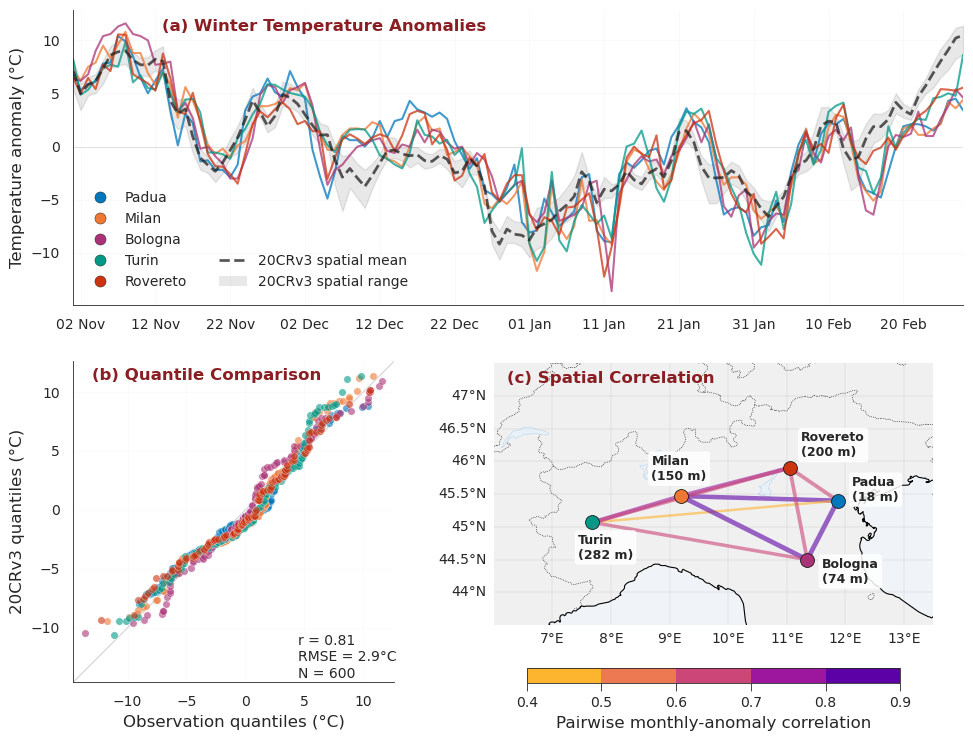

In [27]:
# ── 4. Figure ────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(10, 8))
plt.rcParams.update({'xtick.labelsize': 10, 'ytick.labelsize': 10})
gs = fig.add_gridspec(2, 2, hspace=0.1, wspace=0.22, height_ratios=[.8, 1],
                      width_ratios=[1, 1.5],
                      left=0.06, right=0.95, top=0.95, bottom=0.08)

# --- Panel (a): Time series of anomalies ---
ax_ts = fig.add_subplot(gs[0, :])

for name, s in stations.items():
    ax_ts.plot(s['obs_anom'].index, s['obs_anom'].values, '-', 
               color=colors_sta[name], linewidth=1.5, alpha=0.75, label=f'{name} obs')

# 20CRv3: average the anomalies from all 4 grid cells for a single reference line
# 20CRv3 envelope (min/max shading) + mean line
cr_anoms_all = pd.DataFrame({n: s['cr_anom'] for n, s in stations.items()})
cr_mean_anom = cr_anoms_all.mean(axis=1)
cr_min = cr_anoms_all.min(axis=1)
cr_max = cr_anoms_all.max(axis=1)

ax_ts.fill_between(cr_mean_anom.index, cr_min.values, cr_max.values, 
                    color="#241f1f", alpha=0.10, zorder=1)
ax_ts.plot(cr_mean_anom.index, cr_mean_anom.values, '-', color="#241f1f", linewidth=2, linestyle='--',
           alpha=0.75, zorder=2)
ax_ts.set_xlim([cr_mean_anom.index[0], cr_mean_anom.index[-1]])
ax_ts.axhline(0, color='k', ls='-', alpha=0.15, lw=0.5)
ax_ts.set_ylabel('Temperature anomaly (°C)', fontsize=12)

sta_handles = []
for name in stations:
    sta_handles.append(Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors_sta[name], markersize=8,
                              markeredgecolor='k', markeredgewidth=0.3,
                              label=name, linestyle='None'))

cr_mean_h   = Line2D([0], [0], color='#241f1f', linestyle='--', lw=2, alpha=0.75, label='20CRv3 spatial mean')
cr_spread_h = plt.Rectangle((0, 0), 1, 1, fc='#241f1f', alpha=0.10,
                              edgecolor='none', label='20CRv3 spatial range')

leg1 = ax_ts.legend(handles=sta_handles, fontsize=10,
                    framealpha=0, edgecolor='none',
                    loc='lower left', bbox_to_anchor=(0.0, 0.01))
ax_ts.add_artist(leg1)  # keep leg1 when leg2 is added

leg2 = ax_ts.legend(handles=[cr_mean_h, cr_spread_h], fontsize=10,
                    framealpha=0, edgecolor='none',
                    loc='lower left', bbox_to_anchor=(0.15, 0.01))


# Replace the x-axis formatting block with:
ax_ts.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax_ts.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_ts.tick_params(axis='x', which='minor', length=3)
ax_ts.grid(True, alpha=0.15, lw=0.5)


# --- Pool all station anomalies for scatter and QQ ---
all_obs_anom = []
all_cr_anom = []
for name, s in stations.items():
    all_obs_anom.append(s['obs_anom'].values)
    all_cr_anom.append(s['cr_anom'].values)

all_obs = np.concatenate(all_obs_anom)
all_cr  = np.concatenate(all_cr_anom)

r_val = np.corrcoef(all_obs, all_cr)[0, 1]
rmse  = np.sqrt(np.mean((all_obs - all_cr)**2))
lims = [min(all_obs.min(), all_cr.min()) - 1, max(all_obs.max(), all_cr.max()) + 1]

# --- Panel (b): Scatter plot ---

ax_qq = fig.add_subplot(gs[1, 0])

for name, s in stations.items():
    obs_q = np.sort(s['obs_anom'].values)
    cr_q = np.sort(s['cr_anom'].values)
    ax_qq.scatter(obs_q, cr_q, s=28, alpha=0.6, color=colors_sta[name],
                  edgecolor='white', linewidth=0.3, label=name)
ax_qq.plot(lims, lims, '-', color='#aaaaaa', alpha=0.5, lw=0.8, zorder=0)
ax_qq.set_xlim(lims); ax_qq.set_ylim(lims)
ax_qq.set_aspect('equal')
ax_qq.set_xlabel('Observation quantiles (°C)', fontsize=12)
ax_qq.set_ylabel('20CRv3 quantiles (°C)', fontsize=12)
ax_qq.grid(True, alpha=0.1, lw=0.5)

ax_qq.text(0.7, 0.15,
           f'r = {r_val:.2f}\nRMSE = {rmse:.1f}°C\nN = {len(all_obs)}',
           transform=ax_qq.transAxes, fontsize=10, va='top')


# --- Panel (d): Station map ---

# Get the bounding box of panels (b) and (c) to align panel (d)
fig.canvas.draw()
bb_qq = ax_qq.get_position()

# Panel (d): left edge close to panel (c), bottom aligned with (b)/(c), top near their top
map_left = bb_qq.x1 + 0.1
map_bottom = bb_qq.y0 - 0.05
map_width = 0.92 - map_left
map_height = (bb_qq.y1 - bb_qq.y0) * 1.12

ax_map = fig.add_axes([map_left, map_bottom, map_width, map_height],
                       projection=ccrs.PlateCarree())
ax_map.set_extent([6.0, 13.5, 43.5, 47.5], crs=ccrs.PlateCarree())
ax_map.set_aspect('auto')

# Remove the black frame/border around the map
for spine in ax_map.spines.values():
    spine.set_visible(False)
ax_map.outline_patch.set_visible(False) if hasattr(ax_map, 'outline_patch') else None

# Background
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax_map.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='none', zorder=0)
ax_map.add_feature(cfeature.OCEAN, facecolor='#f0f4f8', zorder=0)
ax_map.add_feature(cfeature.LAKES, facecolor='#e8f0f8', edgecolor='#aaccee', linewidth=0.3)

discrete_colors = sns.color_palette("plasma", 5)[::-1]  # 5 colors for 5 intervals

cmap_disc = ListedColormap(discrete_colors)
norm_disc = BoundaryNorm(boundaries, cmap_disc.N)

for _, r in pairs_df.iterrows():
    color = cmap_disc(norm_disc(r['corr']))
    lw = max(1.5, 4 * r['corr'])
    ax_map.plot([r['lon1'], r['lon2']], [r['lat1'], r['lat2']],
                color=color, linewidth=lw, alpha=0.6, zorder=2,
                transform=ccrs.PlateCarree())

# Station dots + labels — Turin label moved south
label_offsets = {
    'Padua': (0.25, 0), 'Milan': (-.5, 0.25), 'Bologna': (0.25, -0.35),
    'Turin': (-0.25, -0.55), 'Rovereto': (0.2, 0.18),
}
for name, (slat, slon, alt) in station_coords.items():
    c = colors_sta.get(name, 'gray')
    ax_map.plot(slon, slat, 'o', color=c, markersize=10,
                markeredgecolor='k', markeredgewidth=0.6, zorder=5,
                transform=ccrs.PlateCarree())
    dx, dy = label_offsets.get(name, (0.2, 0.15))
    ax_map.annotate(f"{name}\n({alt} m)", xy=(slon, slat),
                    xytext=(slon + dx, slat + dy),
                    fontsize=9, fontweight='bold', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
                    if abs(dx) > 1 or abs(dy) > 0.4 else None,
                    transform=ccrs.PlateCarree())

# Discrete colorbar beneath the map
sm = plt.cm.ScalarMappable(cmap=cmap_disc, norm=norm_disc)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax_map, orientation='horizontal', pad=0.12, shrink=0.85, aspect=25,
                  ticks=boundaries, spacing='uniform')
cb.ax.tick_params(labelsize=10)
cb.set_label('Pairwise monthly-anomaly correlation', fontsize=12)

gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.3)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size':10}
gl.ylabel_style = {'size': 10}

###################### panel labels #################################
ax_ts.text(0.1, 0.97, '(a) Winter Temperature Anomalies', transform=ax_ts.transAxes, fontsize=12, fontweight='bold', va='top', color=unibern)
ax_qq.text(0.06, .98, '(b) Quantile Comparison', transform=ax_qq.transAxes, fontsize=12, fontweight='bold', va='top', color=unibern)
ax_map.text(0.03, 0.97, '(c) Spatial Correlation', transform=ax_map.transAxes, fontsize=12, fontweight='bold', va='top', zorder=10, color=unibern)

###################### save fig #####################################

plt.savefig('image/validation_winter1829-30_poster.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('image/validation_winter1829-30_poster.pdf', bbox_inches='tight', facecolor='white')
print("✓ Saved")
